#  Задача 1.  Вводное задание.



Вектора х1 и у1 из архива дают значения некоторой функции $f(x) .$ Постройте на графике, используя библиотечные функции:

(a) Интерполяционный Лагранжев многочлен.

(b) Интерполяционный кубический сплайн (CubicSpline).

(c) Монотонный кубический интерполянт (PchipInterpolator).

(d)  Аппроксимацию полиномами, используя функции np. polyfit и np.polyval.

Чтобы прочитать из архива данные, используйте следующий код:

In [156]:
import numpy as np
with np.load('data_interp.npz') as data:
  x1, y1 = data['x1'], data['y1']

In [157]:
# (a) Интерполяционный Лагранжев многочлен.

import sympy as smp
from sympy.polys.polyfuncs import interpolate
import matplotlib.pyplot as plt

t = smp.Symbol('t')

points = [(x1[i], y1[i]) for i in range(len(x1))] # Такой формат данных подаётся на вход interpolate

interpolate(points, t)

-1.11368051033974e-65*t**19 + 8.5894176609327e-61*t**18 - 3.03894567841449e-56*t**17 + 6.54400315897786e-52*t**16 - 9.59682775252215e-48*t**15 + 1.01624248636545e-43*t**14 - 8.04013544958794e-40*t**13 + 4.85128018510854e-36*t**12 - 2.25910339570297e-32*t**11 + 8.16407379682308e-29*t**10 - 2.29021106849508e-25*t**9 + 4.96310685387848e-22*t**8 - 8.22349796714838e-19*t**7 + 1.02408934896642e-15*t**6 - 9.33350242244657e-13*t**5 + 5.9735945112013e-10*t**4 - 2.50952353570492e-7*t**3 + 6.11219394825658e-5*t**2 - 0.00639503199436164*t - 0.99

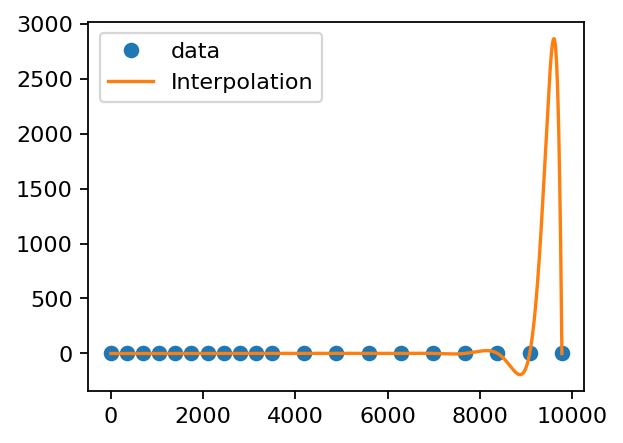

In [158]:
Lagrange = smp.lambdify(t, interpolate(points, t), 'numpy') # Сделаем python функцию из нашего многочлена

xnew = np.linspace(0, 9778, 9778)

plt.figure(figsize=(4, 3), dpi=160)

plt.plot(x1, y1, 'o', xnew, Lagrange(xnew), '-')
plt.legend(['data', 'Interpolation'], loc = 'best')
plt.show()

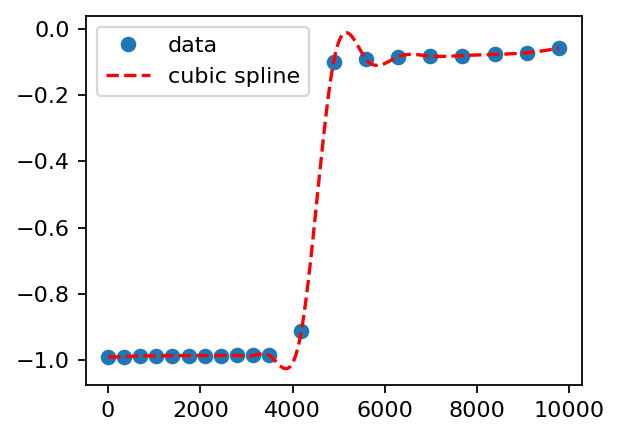

In [159]:
# (b) Интерполяционный кубический сплайн (CubicSpline).

from scipy import interpolate

Spline3 = interpolate.interp1d(x1, y1, kind = 'cubic')
plt.figure(figsize=(4, 3), dpi=160)
plt.plot(x1, y1, 'o', xnew, Spline3(xnew), 'r--')
plt.legend(['data', 'cubic spline'], loc = 'best')

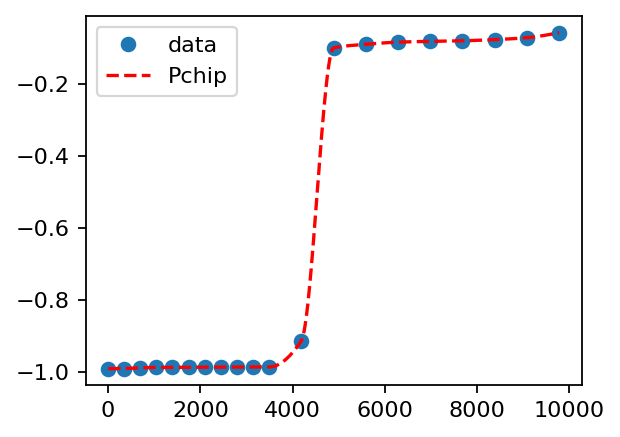

In [160]:
# (c) Монотонный кубический интерполянт (PchipInterpolator).

Pchip = interpolate.PchipInterpolator(x1, y1)
plt.figure(figsize=(4, 3), dpi=160)
plt.plot(x1, y1, 'o', xnew, Pchip(xnew), 'r--')
plt.legend(['data', 'Pchip'], loc = 'best')

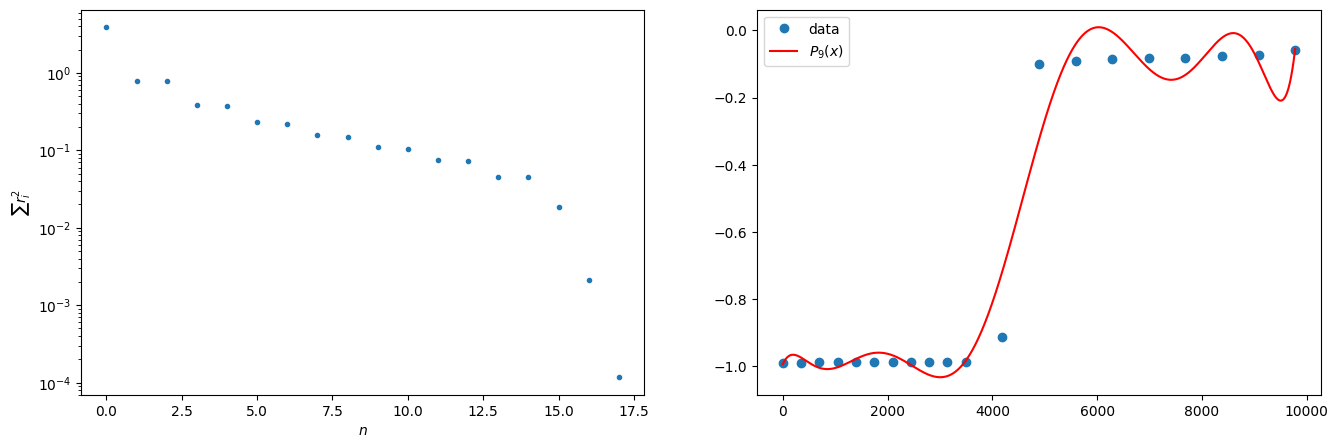

In [161]:
# (d)  Аппроксимацию полиномами, используя функции np.polyfit и np.polyval.

degs = list(range(0, 18))
errs = []
for deg in degs:
    # Сейчас нас интересует только ошибка приближения
    _, [err], *_ =  np.polyfit(x1, y1, deg, full=True)
    errs.append(err)

coeff =  np.polyfit(x1, y1, 9)

plt.figure(figsize=(16, 5))
plt.subplot(1, 2, 1)
plt.semilogy(degs, errs, '.')
# plt.annotate("Optimum", xy=(degs[4], errs[4]), xytext=(3.5, 1e3),
#              arrowprops={"arrowstyle":"-|>"})
plt.xlabel('$n$')
plt.ylabel('$\sum r_i^2$')

plt.subplot(1, 2, 2)
plt.plot(x1, y1, 'o', label='data')
plt.plot(xnew, np.polyval(coeff, xnew), 'r-', label='$P_9(x)$')
plt.legend(loc='best');

# Задача 2. Интерполяция полиномом Лагранжа.



Допишите класс, который конструирует интерполяционный полином Лагранжа, проходящий через точки, заданные как `xk` и `yk`.

In [262]:
import numpy as np
from sympy.polys.polyfuncs import interpolate

class LagrangeInterpolator:
    """Lagrange interpolating polynomial.

    Given a set of pairs ``(x_k, y_k)``, construct
    a Lagrange polynomial ``f(x)``, such that

    .. math::

        f(x_k) = y_k   for k =0, ..., n-1

    Parameters
    ----------
    xk : array_like, shape(n,)
        Abscissas
    yk : array_like, shape(n,)
        Ordinates

    Attributes
    ----------
    __call__

    """
    def __init__(self, xk, yk):
        self.xk = np.asarray(xk, dtype=float)
        self.yk = np.asarray(yk, dtype=float)

    def __call__(self, x):
        """Evaluate the interpolator at a given point.

        Parameters
        ----------
        x : float

        Returns
        -------
        the value of the interpolator at ``x``.
        """
        # YOUR CODE HERE
    
        t = smp.Symbol('t')
        points = [(self.xk[i], self.yk[i]) for i in range(len(self.xk))]

        Lagrange = smp.lambdify(t, interpolate(points, t), 'numpy')
        # if x <= self.xk.max() and x >= self.xk.min():
        return Lagrange(x)
        # else:
        raise NotImplementedError()
    
L = LagrangeInterpolator(x1, y1)
L(2000)

-0.9860108364791615

In [173]:
def runge_func(x, a=25):
    return 1.0 / (1.0 + a*x**2)

xx = np.linspace(-2, 2, 21)
yy = runge_func(xx)

lagr = LagrangeInterpolator(xx, yy)

from numpy.testing import assert_allclose

assert_allclose(yy,
                [lagr(xval) for xval in xx],
                atol=1e-6)


# Задача 3. Феномер Рунге



Рассмотрим функцию Рунге, $y = 1/(1 + 25x^2)$. Интерполируйте эту функцию на интервале $x\in [-2, 2]$, используя полином Лагранжа с $m=3, 5, 7, 11$. Используйте равномерную сетку. Нарисуйте результат интерполяции вместе с исходной функцией на одном графике.

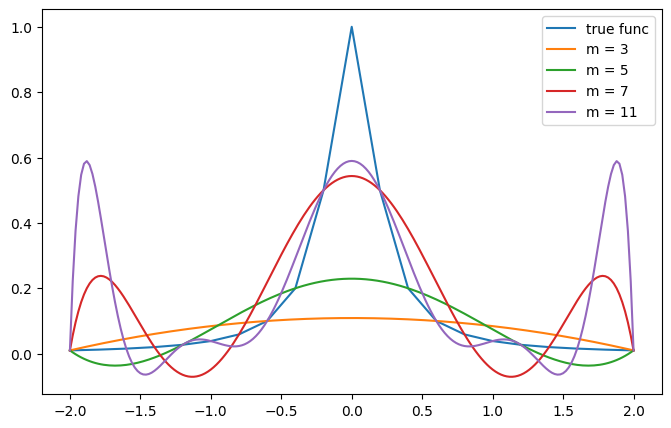

In [182]:
# YOUR CODE AND COMMENTS HERE

plt.figure(figsize=(8,5))
plt.plot(xx, yy, label='true func')
for m in (3, 5, 7, 11):
    mask = [int(i) for i in np.arange(0, 20, 20/m).round()]
    lagr = LagrangeInterpolator(xx[mask], yy[mask])
    xxnew = np.linspace(-2, 2, 201)
    plt.plot(xxnew, lagr(xxnew), label=f'm = {m}')

plt.legend()


Допишите функцию, которая возвращает узлы Чебышева.

In [228]:
def cheb_nodes(n, a=-1, b=1):
    r"""Chebyshev nodes of degree $n$ on $[a, b]$
    """
    # x = np.array([np.cos(2*k - 1) * np.pi/(2*n) for k in range(1, n+1)])
    # return np.sort(x)
    mask = [0 for i in range(n)]
    mask.append(1)
    cheb = np.polynomial.chebyshev.Chebyshev(mask, domain=[a, b])
    return cheb.roots()
    # YOUR CODE HERE
    raise NotImplementedError()



In [229]:
nodes_11 = cheb_nodes(11)
nodes_11 = np.asarray(nodes_11)
assert (nodes_11[1:] > nodes_11[:-1]).all()

from scipy.special import roots_chebyt
nodes, weights = roots_chebyt(5)

assert_allclose(cheb_nodes(5),
                nodes, atol=1e-14)

assert_allclose(cheb_nodes(5, a=-1, b=3),
                nodes*2 + 1, atol=1e-14)

Повторите интерполяцию Лагранжа функции Рунге с помощью узлов Чебышева. Постройте интерполянты.
Также постройте интерполяцию кубическим сплайном тех же данных (`scipy.interpolate.CubicSpline`).
Сравните величину явления Рунге для равномерной сетки и сетки Чебышева. Демонстрирует ли интерполяция сплайнами феномен Рунге?


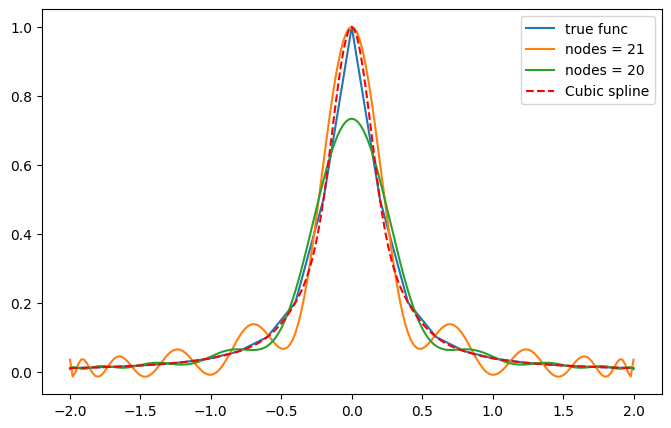

In [240]:
# YOUR CODE AND COMMENTS HERE

from sympy.polys.polyfuncs import interpolate
plt.figure(figsize=(8,5))
plt.plot(xx, yy, label='true func')

lagr = LagrangeInterpolator(cheb_nodes(21, a=-2, b=2), runge_func(cheb_nodes(21, a=-2, b=2)))
xxnew = np.linspace(-2, 2, 201)
plt.plot(xxnew, lagr(xxnew), label=f'nodes = 21')

lagr = LagrangeInterpolator(cheb_nodes(20, a=-2, b=2), runge_func(cheb_nodes(20, a=-2, b=2)))
xxnew = np.linspace(-2, 2, 201)
plt.plot(xxnew, lagr(xxnew), label=f'nodes = 20')

# интерполяция сплайнами


from scipy import interpolate
Spline3 = interpolate.CubicSpline(xx, yy)
plt.plot(xxnew, Spline3(xxnew), 'r--', label='Cubic spline')
plt.legend(['data', 'cubic spline'], loc = 'best')

plt.legend()

Другим известным трудным тестом для интерполяции является следующая периодическая функция:

$u(x)=\frac{\sqrt{\varepsilon(2+\varepsilon)}}{2 \pi(1+\varepsilon-\cos x)}, \quad-\pi \leq x \leq \pi, \quad \varepsilon=0.21  $

Проведите аналогичные вычисления и постройте графики для неё.

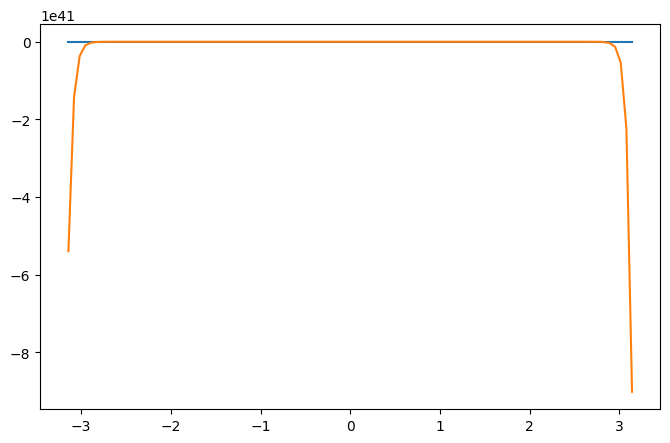

In [266]:
# Lagrangian uniform grid

def periodic_func(x, e=0.21):
    return (np.sqrt(e*(2 + e))/(2 * np.pi * (1 + e - np.cos(x))))

xx = np.linspace(-np.pi, np.pi, 101)
yy = periodic_func(xx)

lagr = LagrangeInterpolator(xx, yy)

plt.figure(figsize=(8, 5))
plt.plot(xx, yy)
plt.plot(xx, lagr(xx))
from numpy.testing import assert_allclose

# assert_allclose(yy,
#                 [lagr(xval) for xval in xx],
#                 atol=1e-6)


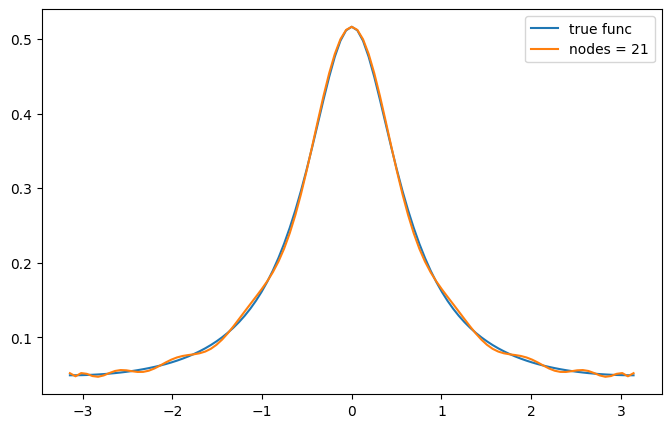

In [269]:
# Lagrangian chebyshev

plt.figure(figsize=(8, 5))
plt.plot(xx, yy, label='true func')
lagr = LagrangeInterpolator(cheb_nodes(21, a=-np.pi, b=np.pi), periodic_func(cheb_nodes(21, a=-np.pi, b=np.pi)))
plt.plot(xx, lagr(xx), label=f'nodes = 21')
plt.legend()

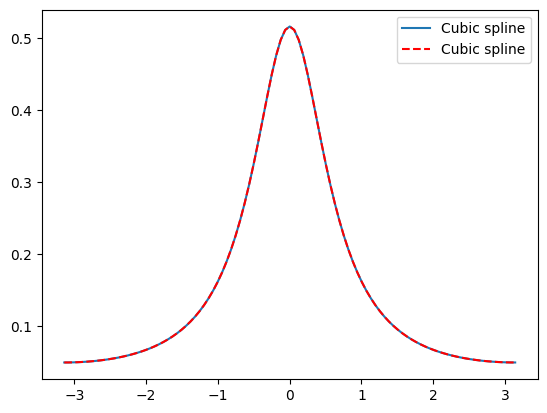

In [270]:
# Cubic spline

from scipy import interpolate
Spline3 = interpolate.CubicSpline(xx, yy)
plt.plot(xx, yy, xx, Spline3(xx), 'r--', label='Cubic spline')
plt.legend(['true func', 'cubic spline'], loc = 'best')

plt.legend()

# Задача 4. Полиномы Чебышева.

Постройте интерполяцию функций

$$
y_{1}(x)=\sin (6 x)+\sin \left(60 e^{x}\right), y_{2}(x)=\frac{1}{1+1000(x+0.5)^{2}}+\frac{1}{\sqrt{1+1000(x-0.5)^{2}}}
$$

на отрезке $[-1,1]$ полиномами Чебышева. Постройте зависимость ошибки приближения от количества узлов. Сколько узлов нужно удержать в каждом из этих случаев для получения достаточно точного приближения?

Text(0.5, 1.0, 'y2')

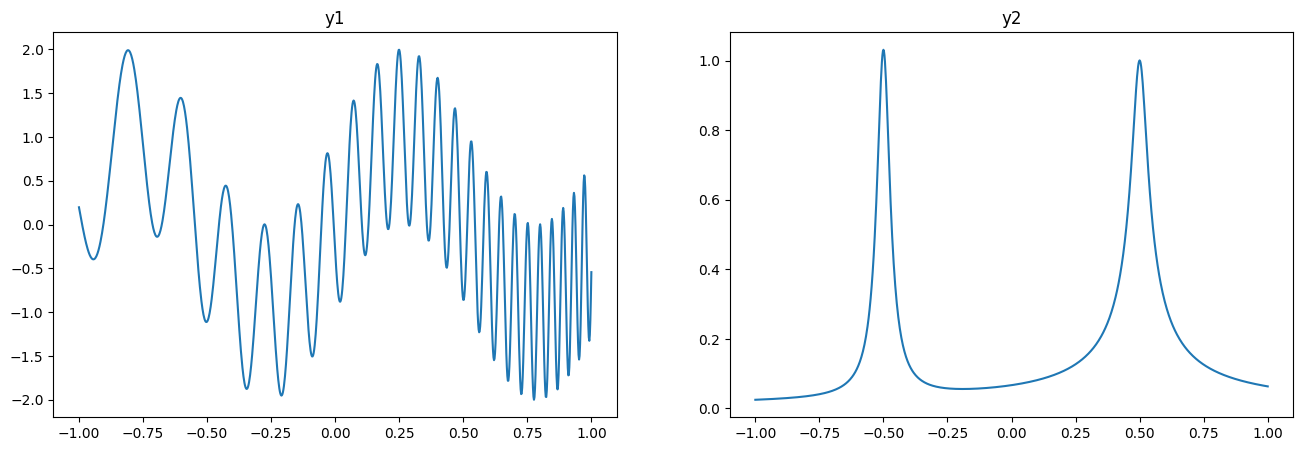

In [287]:
def y1(x):
    return np.sin(6*x) + np.sin(60*np.exp(x))

def y2(x):
    return 1/(1 + 1000*(x + 0.5)**2) + 1/(np.sqrt(1 + 1000*(x-0.5)**2))

x = np.linspace(-1, 1, 1001)

plt.figure(figsize=(16,5))
plt.subplot(1, 2, 1)
plt.plot(x, y1(x))
plt.title('y1')

plt.subplot(1, 2, 2)
plt.plot(x, y2(x))
plt.title('y2')

Text(0.5, 1.0, 'chebyshev approximation y2')

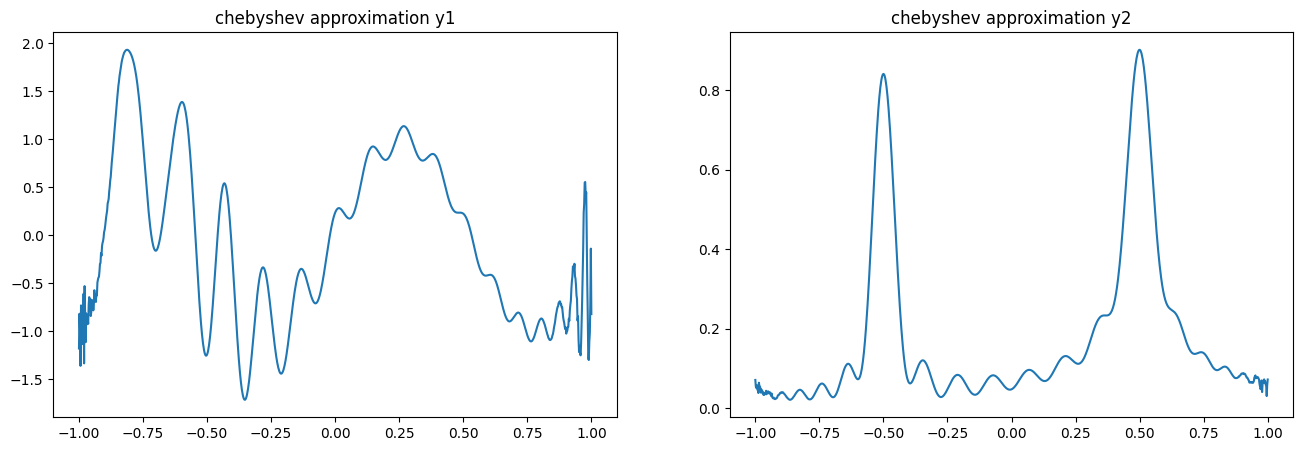

In [341]:
# chebyshev approximation

import numpy as np
Cheb_coef = np.polynomial.chebyshev.chebfit(x, y1(x), deg=46)
coef = np.polynomial.chebyshev.cheb2poly(Cheb_coef)
poly1 = np.polynomial.Polynomial(coef)

Cheb_coef = np.polynomial.chebyshev.chebfit(x, y2(x), deg=45)
coef = np.polynomial.chebyshev.cheb2poly(Cheb_coef)
poly2 = np.polynomial.Polynomial(coef)

plt.figure(figsize=(16,5))
plt.subplot(1, 2, 1)
plt.plot(x, poly1(x))
plt.title('chebyshev approximation y1')

plt.subplot(1, 2, 2)
plt.plot(x, poly2(x))
plt.title('chebyshev approximation y2')

In [321]:
np.sum((poly1(x) - y1(x))**2), x.size

(378.30991253824595, 1001)

Text(0.5, 1.0, 'optimum n for y2')

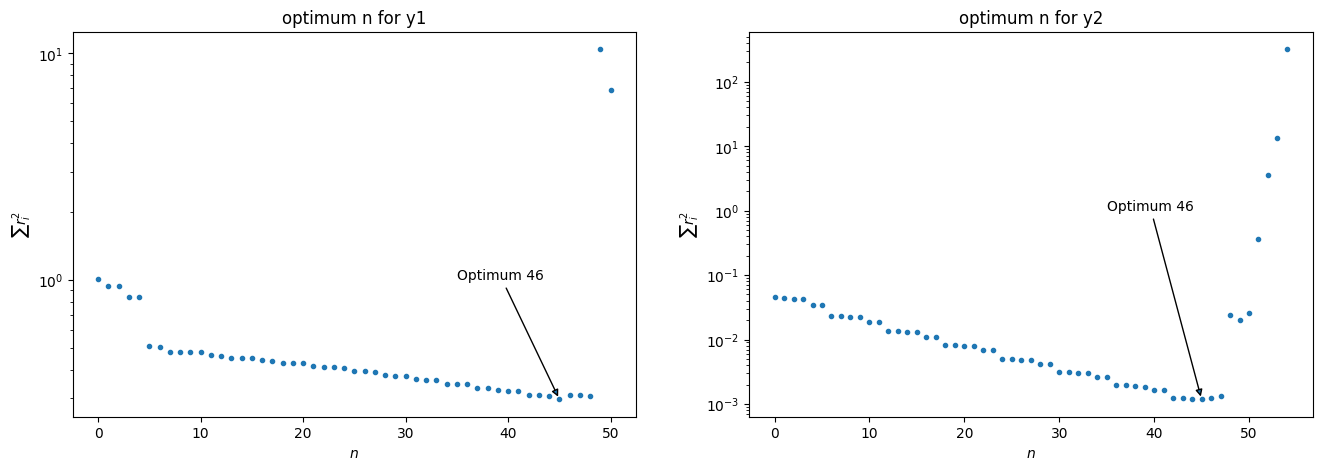

In [340]:
nodes = list(range(0, 51))
errs = []
for n in nodes:
    # Сейчас нас интересует только ошибка приближения
    Cheb_coef = np.polynomial.chebyshev.chebfit(x, y1(x), deg=n)
    coef = np.polynomial.chebyshev.cheb2poly(Cheb_coef)
    poly1 = np.polynomial.Polynomial(coef)
    err = np.sum((poly1(x) - y1(x))**2)/(x.size)
    errs.append(err)

plt.figure(figsize=(16,5))
plt.subplot(1, 2, 1)
plt.semilogy(nodes, errs, '.')
plt.annotate(f"Optimum 46", xy=(nodes[45], errs[45]), xytext=(35, 1),
            arrowprops={"arrowstyle":"-|>"})
plt.xlabel('$n$')
plt.ylabel('$\sum r_i^2$')
plt.title('optimum n for y1')

nodes = list(range(0, 55))
errs = []
for n in nodes:
    # Сейчас нас интересует только ошибка приближения
    Cheb_coef = np.polynomial.chebyshev.chebfit(x, y2(x), deg=n)
    coef = np.polynomial.chebyshev.cheb2poly(Cheb_coef)
    poly2 = np.polynomial.Polynomial(coef)
    err = np.sum((poly2(x) - y2(x))**2)/(x.size)
    errs.append(err)

plt.subplot(1, 2, 2)
plt.semilogy(nodes, errs, '.')
plt.annotate(f"Optimum 46", xy=(nodes[45], errs[45]), xytext=(35, 1),
            arrowprops={"arrowstyle":"-|>"})
plt.xlabel('$n$')
plt.ylabel('$\sum r_i^2$')
plt.title('optimum n for y2')

# Задача 5. Приближение разными функциями.

Вектора х4 и у4 из архива дают значения некоторой функции на равномерной сетке на отрезке [-0.75, 0.75]. Используя scipy . optimize.curve_fit, постройте интерполяцию функции $y(x)$ функциями вида

$$
y_{1}(x)=p_{0}+p_{1} x+p_{2} x^{2}+p_{3} x^{3}+p_{4} x^{4}+p_{5} x^{5}, y_{2}(x)=\frac{p_{0}+p_{1} x+p_{2} x^{2}+p_{3} x^{3}}{1+q_{1} x+q_{2} x^{2}}
$$


Какая из этих формул лучше описывает $y(x)$ на заданном интервале? Постройте график экстраполяции $y(x)$ за пределы исходных данных. Можете ли вы угадать аналитическое выражение для $y(x) ?$

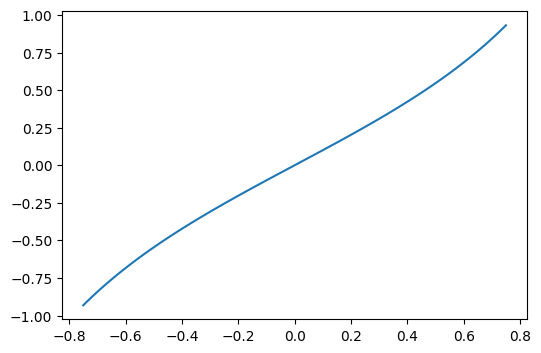

In [344]:
import numpy as np
with np.load('data_interp.npz') as data:
  x4, y4 = data['x4'], data['y4']

  plt.figure(figsize=(6,4))
  plt.plot(x4, y4)

In [361]:
def y1(x, p0, p1, p2, p3, p4, p5):
    return (p0 + p1*x + p2*x**2 + p3*x**3 + p4*x**4 + p5*x**5)

def y2(x, p0, p1, p2, p3, q1, q2):
    return (p0 + p1*x + p2*x**2 + p3*x**3)/(1 + q1*x + q2*x**2)

import scipy
popt1 = scipy.optimize.curve_fit(y1, x4, y4)
popt2 = scipy.optimize.curve_fit(y2, x4, y4)

array([-2.64428657e-09,  1.00131512e+00,  3.27825743e-08,  3.13668685e-01,
       -9.73556789e-08,  2.01784414e-01])

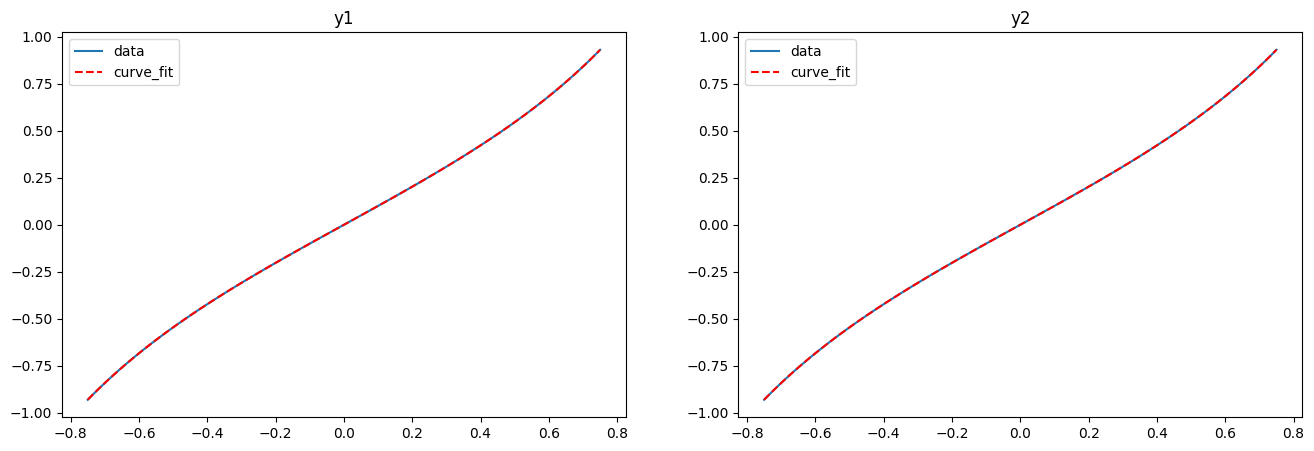

In [371]:
x = np.linspace(-0.75, 0.75, 101)

plt.figure(figsize=(16,5))
plt.subplot(1, 2, 1)
plt.plot(x4, y4, label='data')
plt.plot(x, y1(x, *popt1[0]), 'r--', label='curve_fit')
plt.title('y1')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(x4, y4, label='data')
plt.plot(x, y2(x, *popt2[0]), 'r--', label='curve_fit')
plt.title('y2')
plt.legend()

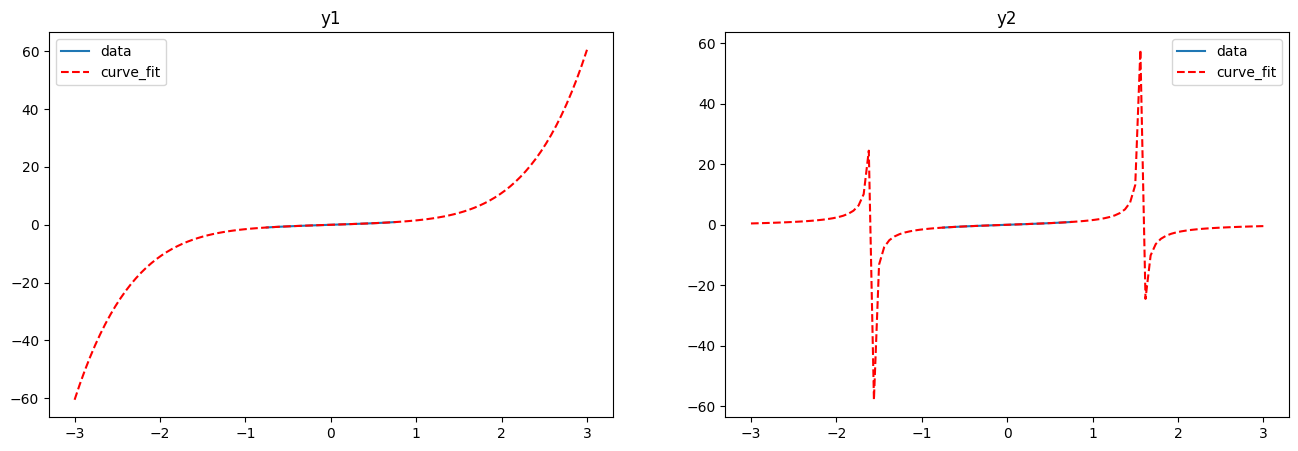

In [372]:
# extrapolate

x = np.linspace(-3, 3, 101)

plt.figure(figsize=(16,5))
plt.subplot(1, 2, 1)
plt.plot(x4, y4, label='data')
plt.plot(x, y1(x, *popt1[0]), 'r--', label='curve_fit')
plt.title('y1')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(x4, y4, label='data')
plt.plot(x, y2(x, *popt2[0]), 'r--', label='curve_fit')
plt.title('y2')
plt.legend()

In [373]:
popt1[0]

array([-2.64428657e-09,  1.00131512e+00,  3.27825743e-08,  3.13668685e-01,
       -9.73556789e-08,  2.01784414e-01])

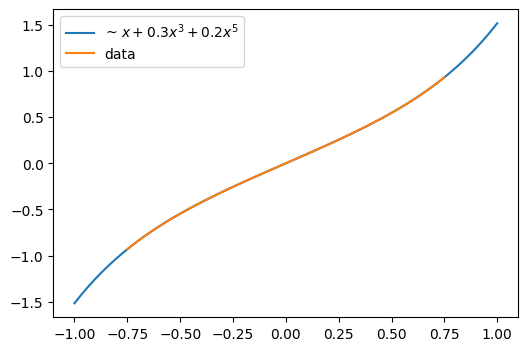

In [386]:
x = np.linspace(-1, 1, 101)
plt.figure(figsize=(6,4))
plt.plot(x, 1.0013*x + 0.3137*x**3 + 0.2018*x**5, label='~ $x + 0.3x^3 + 0.2x^5$')
plt.plot(x4, y4, label='data')
plt.legend()

# Задача 6. Аппроксимация узлов Чебышева.

Вектора х5 и у5 из архива задают некоторую функцию на равномерной сетке на отрезке $[-1,1] .$

Составьте соответствующий интерполяционный многочлен и постройте его график. Ожидаемо, получившийся интерполянт демонстрирует явление Рунге. Теперь проделайте замену переменной $x \rightarrow s$ по формуле $x=g(s)$, где
$$
g(s)=\frac{1}{53089}\left(40320 s+6720 s^{3}+3024 s^{5}+1800 s^{7}+1225 s^{9}\right)
$$

 функция, приближённо отображающая равномерную сетку в сетку узлов Чебышева. В новой переменной $s$, составьте интерполяционный многочлен $P(s) .$ Постройте график получившейся интерполяции исходной функции $P(s(x))$. Делает ли такая процедура явление Рунге менее выраженным?

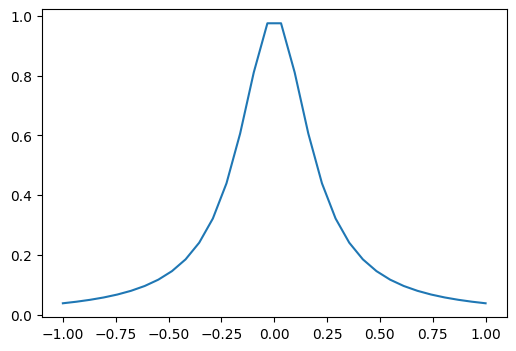

In [387]:
import numpy as np
with np.load('data_interp.npz') as data:
  x5, y5 = data['x5'], data['y5']

  plt.figure(figsize=(6,4))
  plt.plot(x5, y5)

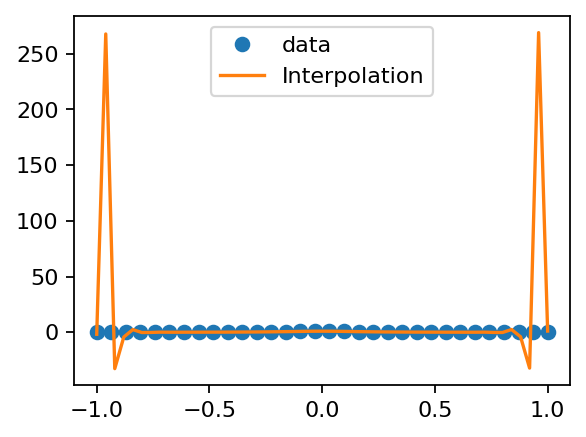

In [419]:
from sympy.polys.polyfuncs import interpolate

t = smp.Symbol('t')
points = [(x5[i], y5[i]) for i in range(len(x5))]
Lagrange = smp.lambdify(t, interpolate(points, t), 'numpy')

xnew = np.linspace(-1, 1, 51)

plt.figure(figsize=(4, 3), dpi=160)

plt.plot(x5, y5, 'o', xnew, Lagrange(xnew), '-')
plt.legend(['data', 'Interpolation'], loc = 'best')

Text(0.5, 1.0, 'map x -> s')

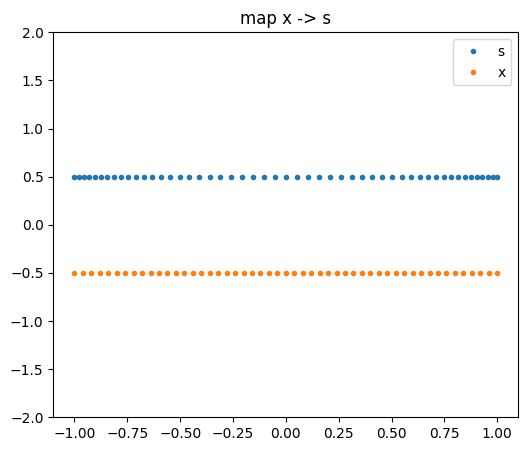

In [420]:
# замена переменной

import scipy

def g(s):
    return ((40320*s + 6720*s**3 + 3024*s**5 + 1800*s**7 + 1225*s**9)/53089)

ss = np.array([])
for x in xnew:
    def f(st, t):
        return g(st) - t
    ss = np.append(ss, scipy.optimize.fsolve(f, 0, args=(x)))

plt.figure(figsize=(6, 5))
plt.plot(ss, np.zeros(51) + 0.5, '.', label='s')
plt.plot(xnew, np.zeros(51) - 0.5, '.', label='x')
plt.ylim((-2, 2))
plt.legend()
plt.title('map x -> s')
 

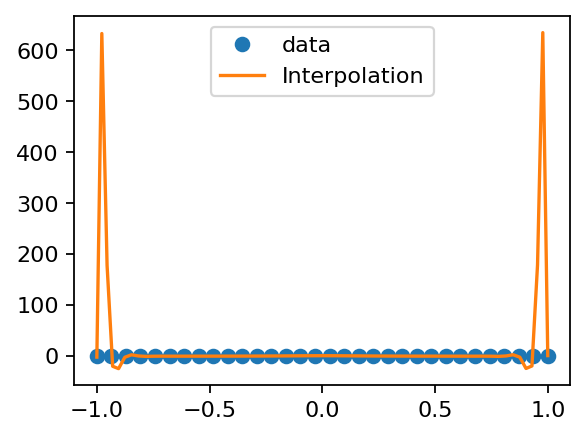

In [422]:
from sympy.polys.polyfuncs import interpolate

t = smp.Symbol('t')
points = [(x5[i], y5[i]) for i in range(len(x5))]
Lagrange = smp.lambdify(t, interpolate(points, t), 'numpy')

xnew = np.linspace(-1, 1, 51)
ss = np.array([])
for x in xnew:
    def f(st, t):
        return g(st) - t
    ss = np.append(ss, scipy.optimize.fsolve(f, 0, args=(x)))

plt.figure(figsize=(4, 3), dpi=160)

plt.plot(x5, y5, 'o', ss, Lagrange(ss), '-')
plt.legend(['data', 'Interpolation'], loc = 'best')